In [2]:
import gradio as gr
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
import pandas as pd
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import netCDF4 as nc
import marineHeatWaves as mhw

In [3]:
data=np.load('20230525HeatBudget&HeatWave_2020_2022.npz')
mltt=np.array(data['mltt'])
Q=np.array(data['Q'])
hadv=np.array(data['hadv'])
lon=np.array(data['lon'])[:-1]
lat=np.array(data['lat'])[:-1]
np.savez('20230525HeatBudget&HeatWave_try.npz',mltt=mltt[:,:-1,:-1],Q=Q[:,:-1,:-1],hadv=hadv[:,:,:],lon=lon,lat=lat)
data=np.load('20230525HeatBudget&HeatWave_try.npz')
ssts=np.load('25_05_2023_oisstv2r01_NEP.npy')
ssta=np.load(r'D:\OneDrive\heat_budget\MHW_HB\2023_5_24汇报\15052023_SSTA_2020_2023_NEP.npy')
data_slp=np.load('SLP&U10&V10.npz')
data.files
#data_slp.files

['mltt', 'Q', 'hadv', 'lon', 'lat']

In [12]:
mltt=np.array(data['mltt'])
Q=np.array(data['Q'])
hadv=np.array(data['hadv'])
lon=np.array(data['lon'])
lat=np.array(data['lat'])
time=pd.date_range('2020-01-01','2022-12-31',freq='1D')
t = np.arange(date(1981,9,1).toordinal(),date(2022,12,31).toordinal()+1)
time_mhw=pd.date_range('1981-09-01','2022-12-31',freq='1D')
ssts_solid=np.nanmean(ssts,axis=-1)
dataset=nc.Dataset(r'F:\OceanData\OISST_2022\oisst-avhrr-v02r01.20220101.nc')    # type: ignore
lons=np.array(dataset.variables['lon'])
lats=np.array(dataset.variables['lat'])
lon_ind=(lons>=150)&(lons<=250)
lat_ind=(lats>=20)&(lats<=60)
Lon,Lat=np.meshgrid(lons[lon_ind],lats[lat_ind])
data_slp=np.load('2023_6_8_slp&u10&v10_ano_after2020.npz')
data_slp.files
msl=np.array(data_slp['msl_a'])
u10_a=np.array(data_slp['u10_a'])
v10_a=np.array(data_slp['v10_a'])
lons=np.array(np.load('lons&lats_V_old.npz')['lon'])[:-1]
lats=np.array(np.load('lons&lats_V_old.npz')['lat'])[:-1]

C:\Users\XUEX\AppData\Local\Temp\ipykernel_11300\2504509736.py:9: RuntimeWarning: Mean of empty slice
  ssts_solid=np.nanmean(ssts,axis=-1)


In [7]:
ssta=np.load(r'15052023_SSTA_2020_2023_NEP.npy')

In [35]:
np.load('25_05_2023_oisstv2r01_NEP.npy').shape

(160, 400, 15097)

C:\Users\XUEX\AppData\Local\Temp\ipykernel_30188\1288321864.py:32: RuntimeWarning: Mean of empty slice
  ssta_n=np.nanmean(ssta[:,:,timeind],axis=-1)


190 225 35 45 20210701 20211031


'D:\\OneDrive\\heat_budget\\MHW_HB\\2023_5_24汇报\\png.png'

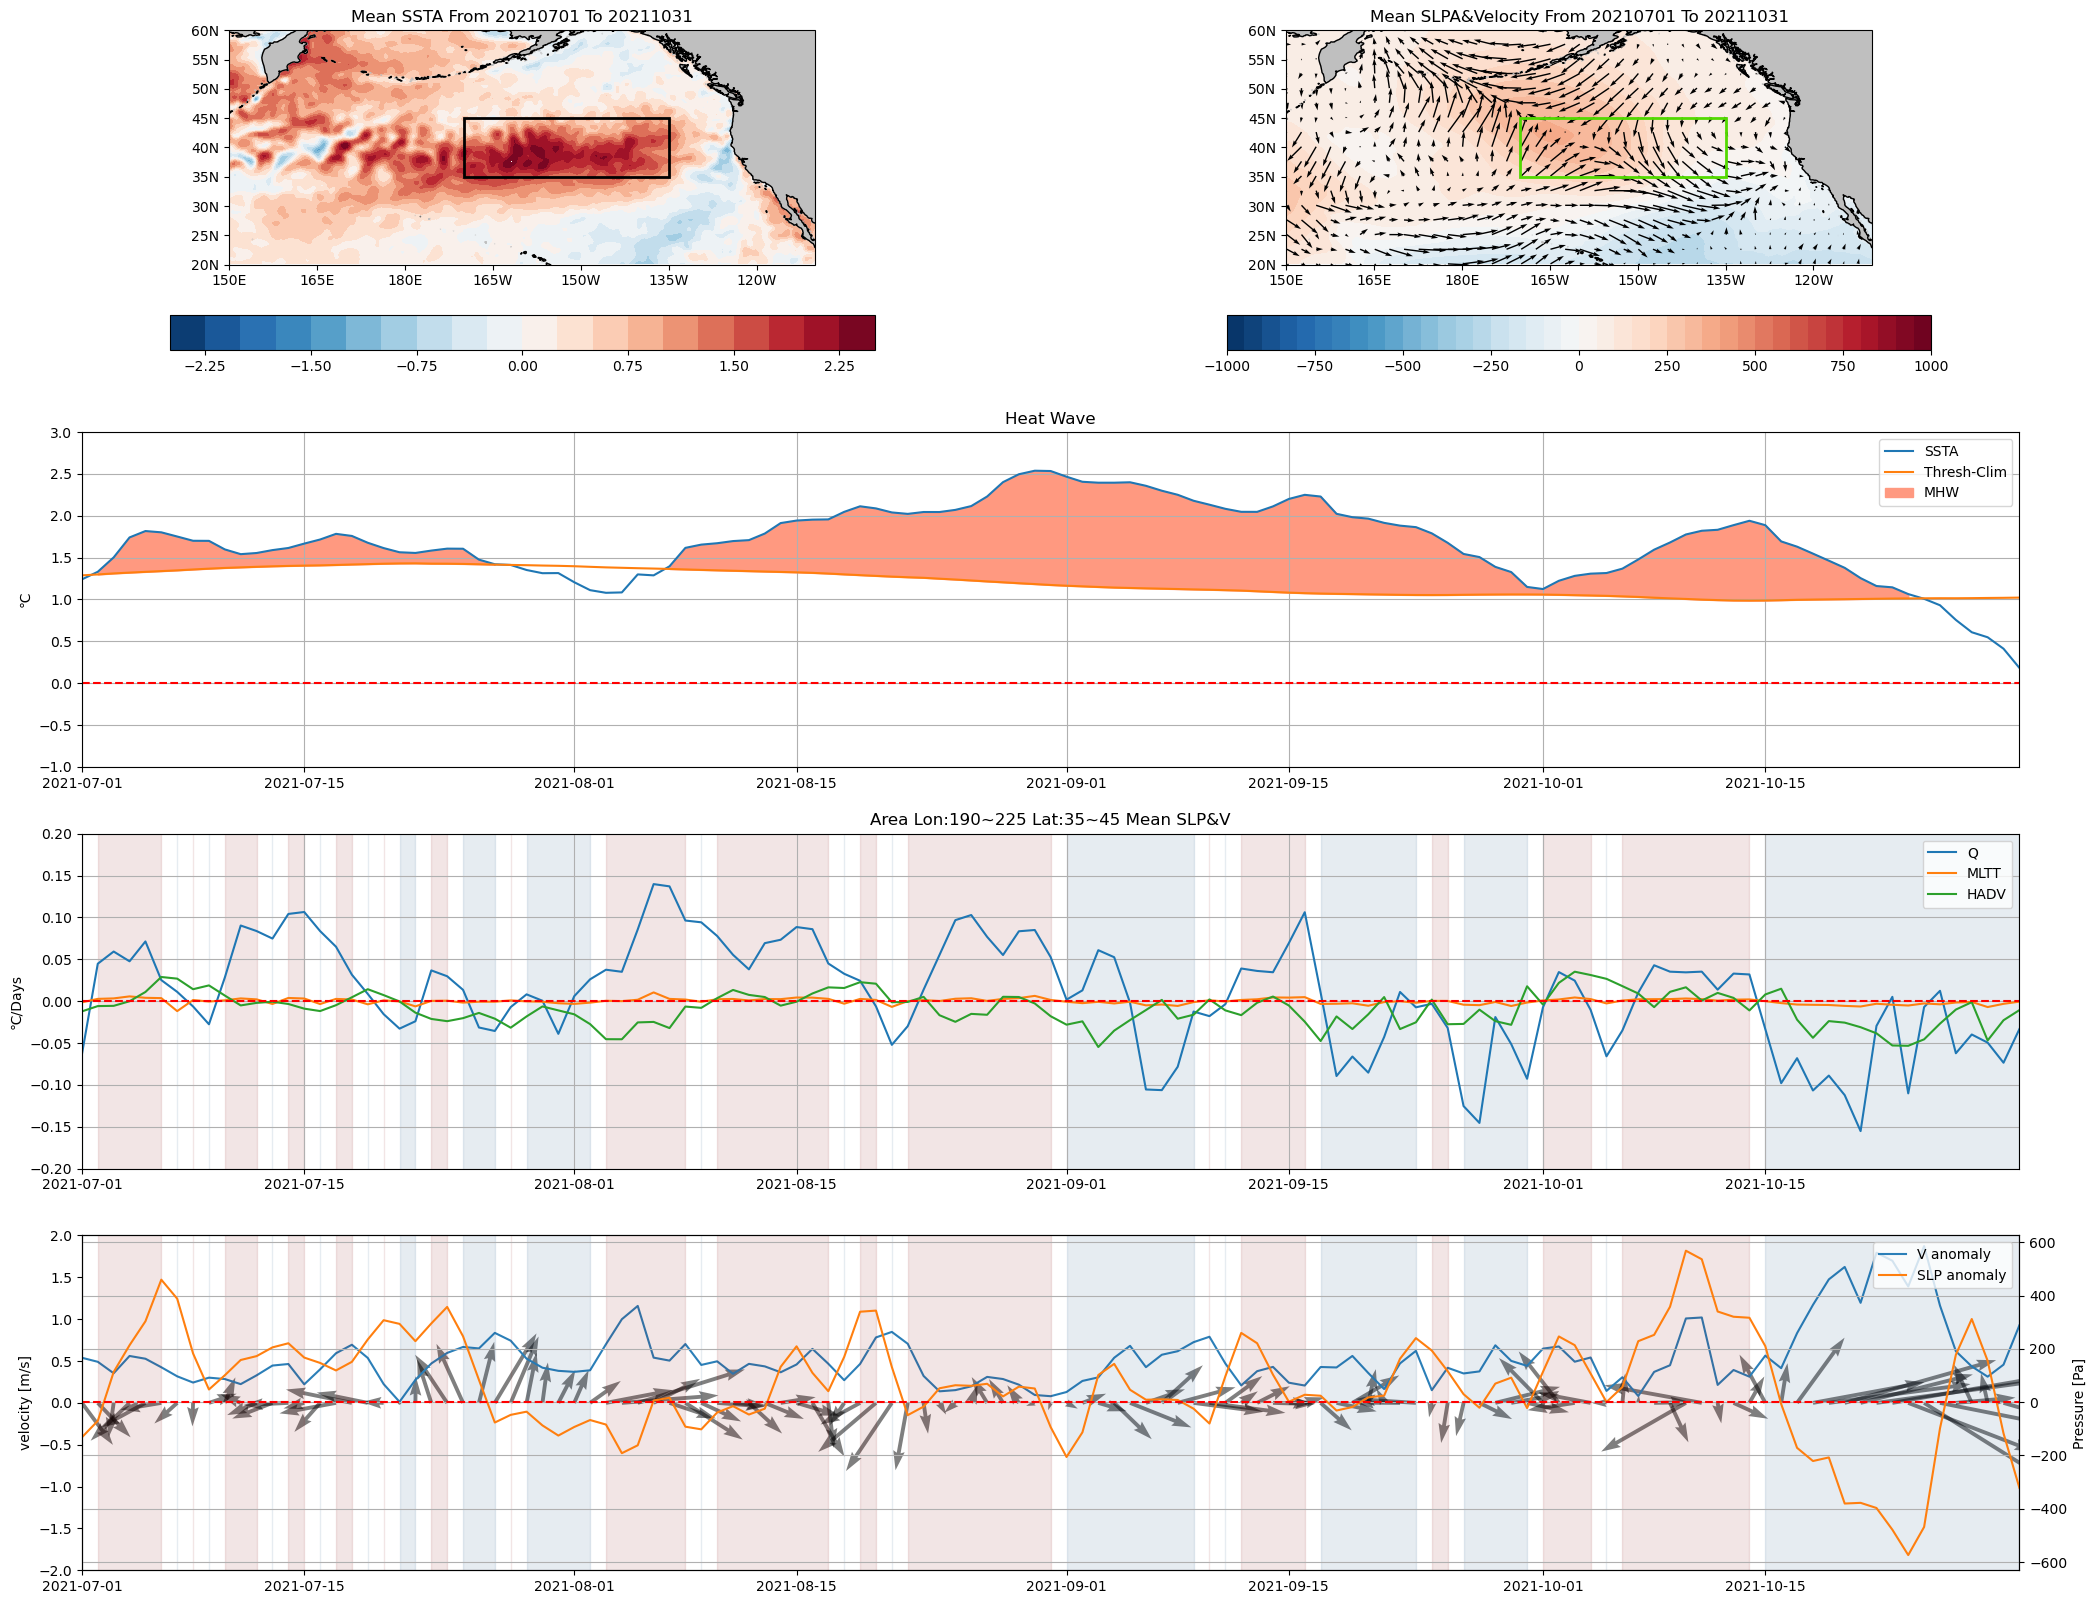

In [80]:
def plot_sea_surface_temperature(left_lon, right_lon, lower_lat, upper_lat, start_date, end_date):
    global data
    global lon
    global lons
    global lat
    global lats
    global time
    global t
    global time_mhw
    global Lon
    global Lat
    
    lonind=(lon>=left_lon)&(lon<=right_lon)
    latind=(lat>=lower_lat)&(lat<=upper_lat)
    timeind=(time>=pd.to_datetime(start_date))&(time<=pd.to_datetime(end_date))
    # print(lonind.shape,latind.shape,timeind.shape)
    # print(np.array(data['mltt'])[timeind,:,:].shape)
    # print(np.array(data['mltt'])[timeind,:,:][:,latind,:].shape)
    mltt=np.array(data['mltt'])[timeind,:,:][:,latind,:][:,:,lonind]/24
    Q=np.array(data['Q'])[timeind,:,:][:,latind,:][:,:,lonind]
    hadv=np.array(data['hadv'])[timeind,:,:][:,latind,:][:,:,lonind]
    ovmix=mltt-Q-hadv
    y0=np.zeros(shape=[time[timeind].shape[0]])
    y1=np.copy(y0)
    y1[:]=10000
    y0[:]=-10000
    plt.figure(figsize=[25,20])

    ax=plt.subplot(4,2,1,projection=ccrs.PlateCarree(central_longitude=180))
    plt.title(f'Mean SSTA From {start_date} To {end_date}')
    timemhw_ind=(time_mhw>=pd.to_datetime(start_date))&(time_mhw<=pd.to_datetime(end_date))
    ssta_n=np.nanmean(ssta[:,:,timeind],axis=-1)
    ma=int(np.nanmax(np.abs(ssta_n)))
    c=ax.contourf(Lon,Lat,ssta_n,np.arange(-1*ma-0.5,ma+0.5+0.1,0.25),transform=ccrs.PlateCarree(central_longitude=0),cmap='RdBu_r')
    plt.colorbar(c,ax=ax,orientation="horizontal",extend='both',shrink=0.8)
    ax.set_xticks(range(150-180, 250-180+1, 15))
    ax.set_yticks(range(20, 60+1, 5))
    ax.set_xlim(150-180, 250-180)
    ax.set_ylim(20, 60)
    import matplotlib.patches as patches
    rect = patches.Rectangle((left_lon-180, lower_lat),right_lon-left_lon, upper_lat-lower_lat, linewidth=2, edgecolor='k', facecolor='none')
    ax.add_patch(rect)# 将矩形添加到ax中
    lon_formatter = LongitudeFormatter(number_format='.0f',
                                        degree_symbol='',
                                        dateline_direction_label=True)
    lat_formatter = LatitudeFormatter(number_format='.0f',
                                        degree_symbol='')
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    
    scale = '10m'
    land = cfeature.NaturalEarthFeature(
        'physical', 'land', scale, edgecolor='face', facecolor=cfeature.COLORS['land'])
    ax.add_feature(land, facecolor='0.75') # type: ignore
    ax.coastlines() # type: ignore
    
    
    ################################################################
    ax=plt.subplot(4,2,2,projection=ccrs.PlateCarree(central_longitude=180))
    plt.title(f'Mean SLPA&Velocity From {start_date} To {end_date}')
    msl_d=np.mean(msl[timeind,:,:],axis=0)[1:,1:]
    u10_d=np.mean(u10_a[timeind,:,:],axis=0)[1:,1:]
    v10_d=np.mean(v10_a[timeind,:,:],axis=0)[1:,1:]
    ma=int(np.nanmax(np.abs(msl))/100)+1
    c=ax.contourf(Lon,Lat,msl_d,np.arange(-1000,1001,50),cmap='RdBu_r',transform=ccrs.PlateCarree(central_longitude=0))
    ax.contourf(Lon,Lat,msl_d,[-10000,-1000],colors=['#082545'],transform=ccrs.PlateCarree(central_longitude=0))
    ax.contourf(Lon,Lat,msl_d,[1001,10000],colors=['#490414'],transform=ccrs.PlateCarree(central_longitude=0))
    plt.colorbar(c,ax=ax,orientation="horizontal",extend='both',shrink=0.8)
    sep=10;ax.quiver(Lon[::sep,::sep],Lat[::sep,::sep],u10_d[::sep,::sep],v10_d[::sep,::sep],transform=ccrs.PlateCarree(central_longitude=0))
    ax.set_xticks(range(150-180, 250-180+1, 15))
    ax.set_yticks(range(20, 60+1, 5))
    ax.set_xlim(150-180, 250-180)
    ax.set_ylim(20, 60)
    import matplotlib.patches as patches
    rect = patches.Rectangle((left_lon-180, lower_lat),right_lon-left_lon, upper_lat-lower_lat, linewidth=2, edgecolor='#52d900', facecolor='none')
    ax.add_patch(rect)# 将矩形添加到ax中
    lon_formatter = LongitudeFormatter(number_format='.0f',
                                        degree_symbol='',
                                        dateline_direction_label=True)
    lat_formatter = LatitudeFormatter(number_format='.0f',
                                        degree_symbol='')
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    
    scale = '10m'
    land = cfeature.NaturalEarthFeature(
        'physical', 'land', scale, edgecolor='face', facecolor=cfeature.COLORS['land'])
    ax.add_feature(land, facecolor='0.75') # type: ignore
    ax.coastlines() # type: ignore
    ################################################################

    plt.subplot(4,2,(3,4))
    plt.title('Heat Wave')
    datas=np.load('25_05_2023_oisstv2r01_NEP.npy')[(lats>=lower_lat)&(lats<=upper_lat),:,:][:,(lons>=left_lon)&(lons<=right_lon),:]
    sst=np.nanmean(np.nanmean(datas,axis=0),axis=0)
    mhws, clim = mhw.detect(t, sst)
    plt.plot(time_mhw,sst-np.array(clim['seas']),label='SSTA')
    plt.plot(time_mhw,np.array(clim['thresh'])-np.array(clim['seas']),label='Thresh-Clim')
    ev = np.argmax(mhws['intensity_max']) # Find largest event
    t1 = np.where(t==mhws['time_start'][0])[0][0]
    t2 = np.where(t==mhws['time_end'][0])[0][0]
    plt.fill_between(time_mhw[t1:t2+1], sst[t1:t2+1], clim['thresh'][t1:t2+1],color=(1,0.6,0.5),label='MHW')
    plt.legend()
    plt.axhline(y=0, color='r', linestyle='--')
    for ev0 in range(1,mhws['n_events']):
        t1 = np.where(t==mhws['time_start'][ev0])[0][0]
        t2 = np.where(t==mhws['time_end'][ev0])[0][0]
        plt.fill_between(time_mhw[t1:t2+1], (sst-np.array(clim['seas']))[t1:t2+1], (np.array(clim['thresh'])-np.array(clim['seas']))[t1:t2+1],color=(1,0.6,0.5))
    plt.xlim(time[timeind][0],time[timeind][-1])
    plt.ylabel('℃')
    plt.grid()
    plt.ylim(int(np.nanmin((sst-np.array(clim['seas']))[timemhw_ind]))-1,int(np.nanmax((sst-np.array(clim['seas']))[timemhw_ind]))+1)

    
    ################################################################
    
    
    plt.subplot(4,2,(5,6))
    plt.title('Heat Budget')
    plt.plot(time[timeind],np.nanmean(np.nanmean(Q,axis=-1),axis=-1),label='Q')
    plt.plot(time[timeind],np.nanmean(np.nanmean(mltt,axis=-1),axis=-1),label='MLTT')
    plt.plot(time[timeind],np.nanmean(np.nanmean(hadv,axis=-1),axis=-1),label='HADV')
    #pltsea of thieves Ocean.plot(time[:-1],np.nanmean(np.nanmean(ovmix1,axis=-1),axis=-1),label='ENT')
    #plt.plot(time,np.nanmean(np.nanmean(ovmix2,axis=-1),axis=-1),label='MIX')
    #plt.plot(time[timeind],np.nanmean(np.nanmean(ovmix,axis=-1),axis=-1),label='OVMIX')
    plt.legend()
    plt.axhline(y=0, color='r', linestyle='--')
    plt.fill_between(
        time[timeind],
        y0,
        y1,
        where=np.nanmean(np.nanmean(mltt, axis=-1), axis=-1) > 0,
        alpha=0.1,
        color='#840000',
    )
    plt.fill_between(
        time[timeind],
        y0,
        y1,
        where=np.nanmean(np.nanmean(mltt, axis=-1), axis=-1) < 0,
        alpha=0.1,
        color='#10457e',
    )
    plt.ylim(-0.2,0.2)
    plt.xlim(time[timeind][0],time[timeind][-1])
    plt.ylabel('℃/Days')
    #plt.xlabel('Time[Days]')
    plt.grid()
    ################################################################
    plt.title(f'Area Lon:{left_lon}~{right_lon} Lat:{lower_lat}~{upper_lat} Mean SLP&V')
    plt.subplot(4,2,(7,8))
    ax=plt.gca()
    ax.quiver(time[timeind],
               np.zeros(shape=[time[timeind].shape[0]]),
               np.mean(u10_a[timeind,:,:],axis=(1,2)),
               np.mean(v10_a[timeind,:,:],axis=(1,2)),
               width=0.002,
               scale=20,
               alpha=0.5,
               label='velocity')
    ax.plot(time[timeind],(np.mean(u10_a[timeind,:,:],axis=(1,2))**2+np.mean(v10_a[timeind,:,:],axis=(1,2))**2)**0.5,c='#2b7fb8')
    ax.set_ylim(-2,2)
    plt.ylabel('velocity [m/s]')
    ax2=ax.twinx()
    ax2.plot([0,1],[0,1],c='#2b7fb8',label='V anomaly')
    ax2.plot([0,1],[0,1],c='#ff7f0f',label='SLP anomaly')
    plt.legend()
    
    ax2.plot(time[timeind],np.mean(msl[timeind,:,:],axis=(1,2)),c='#ff7f0f')
    plt.ylim(ax2.get_ylim())
    plt.fill_between(
        time[timeind],
        y0,
        y1,
        where=np.nanmean(np.nanmean(mltt, axis=-1), axis=-1) > 0,
        alpha=0.1,
        color='#840000',
    )
    plt.fill_between(
        time[timeind],
        y0,
        y1,
        where=np.nanmean(np.nanmean(mltt, axis=-1), axis=-1) < 0,
        alpha=0.1,
        color='#10457e',
    )
    
    
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlim(time[timeind][0],time[timeind][-1])
    plt.ylabel('Pressure [Pa]')
    plt.xlabel('Time[Days]')
    plt.grid()
    
    
    plt.savefig(r'D:\OneDrive\heat_budget\MHW_HB\2023_5_24汇报\png.png')
    print(left_lon, right_lon, lower_lat, upper_lat, start_date, end_date)

    # 返回图片路径供Gradio使用
    return r'D:\OneDrive\heat_budget\MHW_HB\2023_5_24汇报\png.png'

    # 返回图片路径供Gradio使用
    # return r'D:\OneDrive\heat_budget\MHW_HB\2023_5_24汇报\数据下载.png'
plot_sea_surface_temperature(190, 250-25, 35, 45, '20210701', '20211031')

In [21]:
data_slp=np.load('2023_6_8_slp&u10&v10_ano_after2020.npz')
data_slp.files
msl_a=np.array(data_slp['msl_a'])
u10_a=np.array(data_slp['u10_a'])
v10_a=np.array(data_slp['v10_a'])

In [22]:
lls=("lon&latForSLP.npz")
Lonslp,Latslp=np.meshgrid(np.load(lls)['lon'],np.load(lls)['lat'])

Text(0.5, 1.0, '2021-07-01 to 2021-07-16')

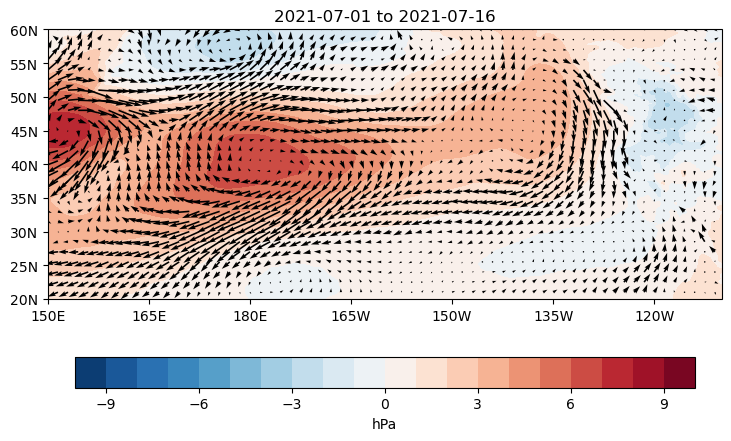

In [26]:
timeind=(time>=pd.to_datetime('2021-07-01'))&(time<=pd.to_datetime('2021-07-16'))
plt.figure(figsize=(10,5))
ax=plt.subplot(projection=ccrs.PlateCarree(central_longitude=180))
c=ax.contourf(Lonslp,Latslp,np.nanmean(msl_a[timeind,:,:],axis=0)/100,np.arange(-10,11,1),cmap='RdBu_r',transform=ccrs.PlateCarree(central_longitude=0))
plt.colorbar(c,label='hPa',ax=ax,orientation="horizontal",extend='both',shrink=0.8)
ax.set_xticks(range(150-180, 250-180+1, 15))
ax.set_yticks(range(20, 60+1, 5))
ax.set_xlim(150-180, 250-180)
ax.set_ylim(20, 60)
lon_formatter = LongitudeFormatter(number_format='.0f',
                                    degree_symbol='',
                                    dateline_direction_label=True)
lat_formatter = LatitudeFormatter(number_format='.0f',
                                    degree_symbol='')
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)

#ax.coastlines('50m')
seq=6;ax.quiver(Lonslp[::seq,::seq],Latslp[::seq,::seq],np.nanmean(u10_a[timeind,:,:],axis=0)[::seq,::seq],np.nanmean(v10_a[timeind,:,:],axis=0)[::seq,::seq],transform=ccrs.PlateCarree(central_longitude=0))
plt.title(f'{time[timeind][0].strftime("%Y-%m-%d")} to {time[timeind][-1].strftime("%Y-%m-%d")}')

In [ ]:
u10_dm